## Concat Projections

### Check CUDA is Available

In [1]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


In [2]:
torch.cuda.set_device(1)
print(f"Current device: {torch.cuda.current_device()}")
print(f"Device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Current device: 1
Device name: NVIDIA GeForce RTX 2080 Ti


### Import Necessary Libraries

In [3]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from transformers import T5Tokenizer, T5ForConditionalGeneration

import torchmetrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score

from model_projections import (
    FeatureProjector,
    MultitaskModelWithProjection,
    ProjectionExperimentDataset,
    create_experiment_pipeline,
    evaluate_with_sampling,
    train,
    train_and_validate_model_with_meteor_rouge,
    train_and_validate_model_with_meteor_stopping,
    METEOREarlyStopping,
    display_generated_texts,
    print_test_evaluation,
    compute_rougeL
)


### Set Random Seed for Reproducibility

In [4]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

### Load Dataset and Extract Features

In [5]:
mwr_df = pd.read_csv('mwr.csv')

In [6]:
print(mwr_df.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'y_binary'],
      dtype='object')


In [7]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split Data into Test and Train

In [8]:
# 70% training, 15% validation, 15% testing
from sklearn.model_selection import train_test_split

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

## Concat Projections + Full Text

### Initialise Model

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='concat',         
    projection_type='mlp',         
    use_minimal_text=False,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: CONCAT projection + FULL text
Projection type: mlp


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: False
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.6158
Classification loss: 0.6316
Generation loss: 1.8553
Weighted gen loss: 18.552640
Validation loss: 10.6315
Validation metrics:
  Accuracy     : 0.7169
  F1-Score     : 0.7101
  Sensitivity  : 0.8336
  Specificity  : 0.3512
  AUC-ROC      : 0.6760

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4178
  ✓ New best METEOR: 0.4178
  ROUGE-L F1   : 0.4146
  ✓ New best ROUGE-L F1: 0.4146
✓ New best accuracy: 0.7169
✓ New best F1: 0.7101
✓ New best AUC-ROC: 0.6760

Epoch 2/50
Training loss: 11.2966
Classification loss: 0.5515
Generation loss: 1.1241
Weighted gen loss: 11.241459
Validation loss: 9.2773
Validation metrics:
  Accuracy     : 0.7318
  F1-Score     : 0.7225
  Sensitivity  : 0.8511
  Specificity  : 0.3580
  AUC-ROC      : 0.6955

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.4228
  ROUGE-L F1   : 0.4138
✓ New best AUC-ROC: 0.8091

Epoch 17/50
Training loss: 7.1714
Classification loss: 0.4588
Generation loss: 0.7125
Weighted gen loss: 7.125489
Validation loss: 6.6796
Validation metrics:
  Accuracy     : 0.7679
  F1-Score     : 0.7752
  Sensitivity  : 0.8122
  Specificity  : 0.6294
  AUC-ROC      : 0.8137

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4225
  ROUGE-L F1   : 0.4154
  ✓ New best ROUGE-L F1: 0.4154
✓ New best AUC-ROC: 0.8137

Epoch 18/50
Training loss: 7.1002
Classification loss: 0.4564
Generation loss: 0.7055
Weighted gen loss: 7.054590
Validation loss: 6.6824
Validation metrics:
  Accuracy     : 0.7621
  F1-Score     : 0.7687
  Sensitivity  : 0.8129
  Specificity  : 0.6032
  AUC-ROC      : 0.8082

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (36

Validation loss: 6.0360
Validation metrics:
  Accuracy     : 0.7784
  F1-Score     : 0.7829
  Sensitivity  : 0.8325
  Specificity  : 0.6089
  AUC-ROC      : 0.8265

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4215
  ROUGE-L F1   : 0.4169
✓ New best accuracy: 0.7784
✓ New best F1: 0.7829
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.2763
Classification loss: 0.4318
Generation loss: 0.6233
Weighted gen loss: 6.233160
Validation loss: 6.0257
Validation metrics:
  Accuracy     : 0.7517
  F1-Score     : 0.7643
  Sensitivity  : 0.7688
  Specificity  : 0.6978
  AUC-ROC      : 0.8236

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4245
  ROUGE-L F1   : 0.4206

Epoch 35/50
Training loss: 6.2363
Classification loss: 0.4332
Generation loss: 0.6193
Weigh

Computing text metrics on 3624 samples...
  METEOR Score : 0.4281
  ROUGE-L F1   : 0.4212

Epoch 50/50
Training loss: 5.8282
Classification loss: 0.4134
Generation loss: 0.5787
Weighted gen loss: 5.786817
Validation loss: 5.8124
Validation metrics:
  Accuracy     : 0.7757
  F1-Score     : 0.7824
  Sensitivity  : 0.8187
  Specificity  : 0.6408
  AUC-ROC      : 0.8308

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4176
  ROUGE-L F1   : 0.4130


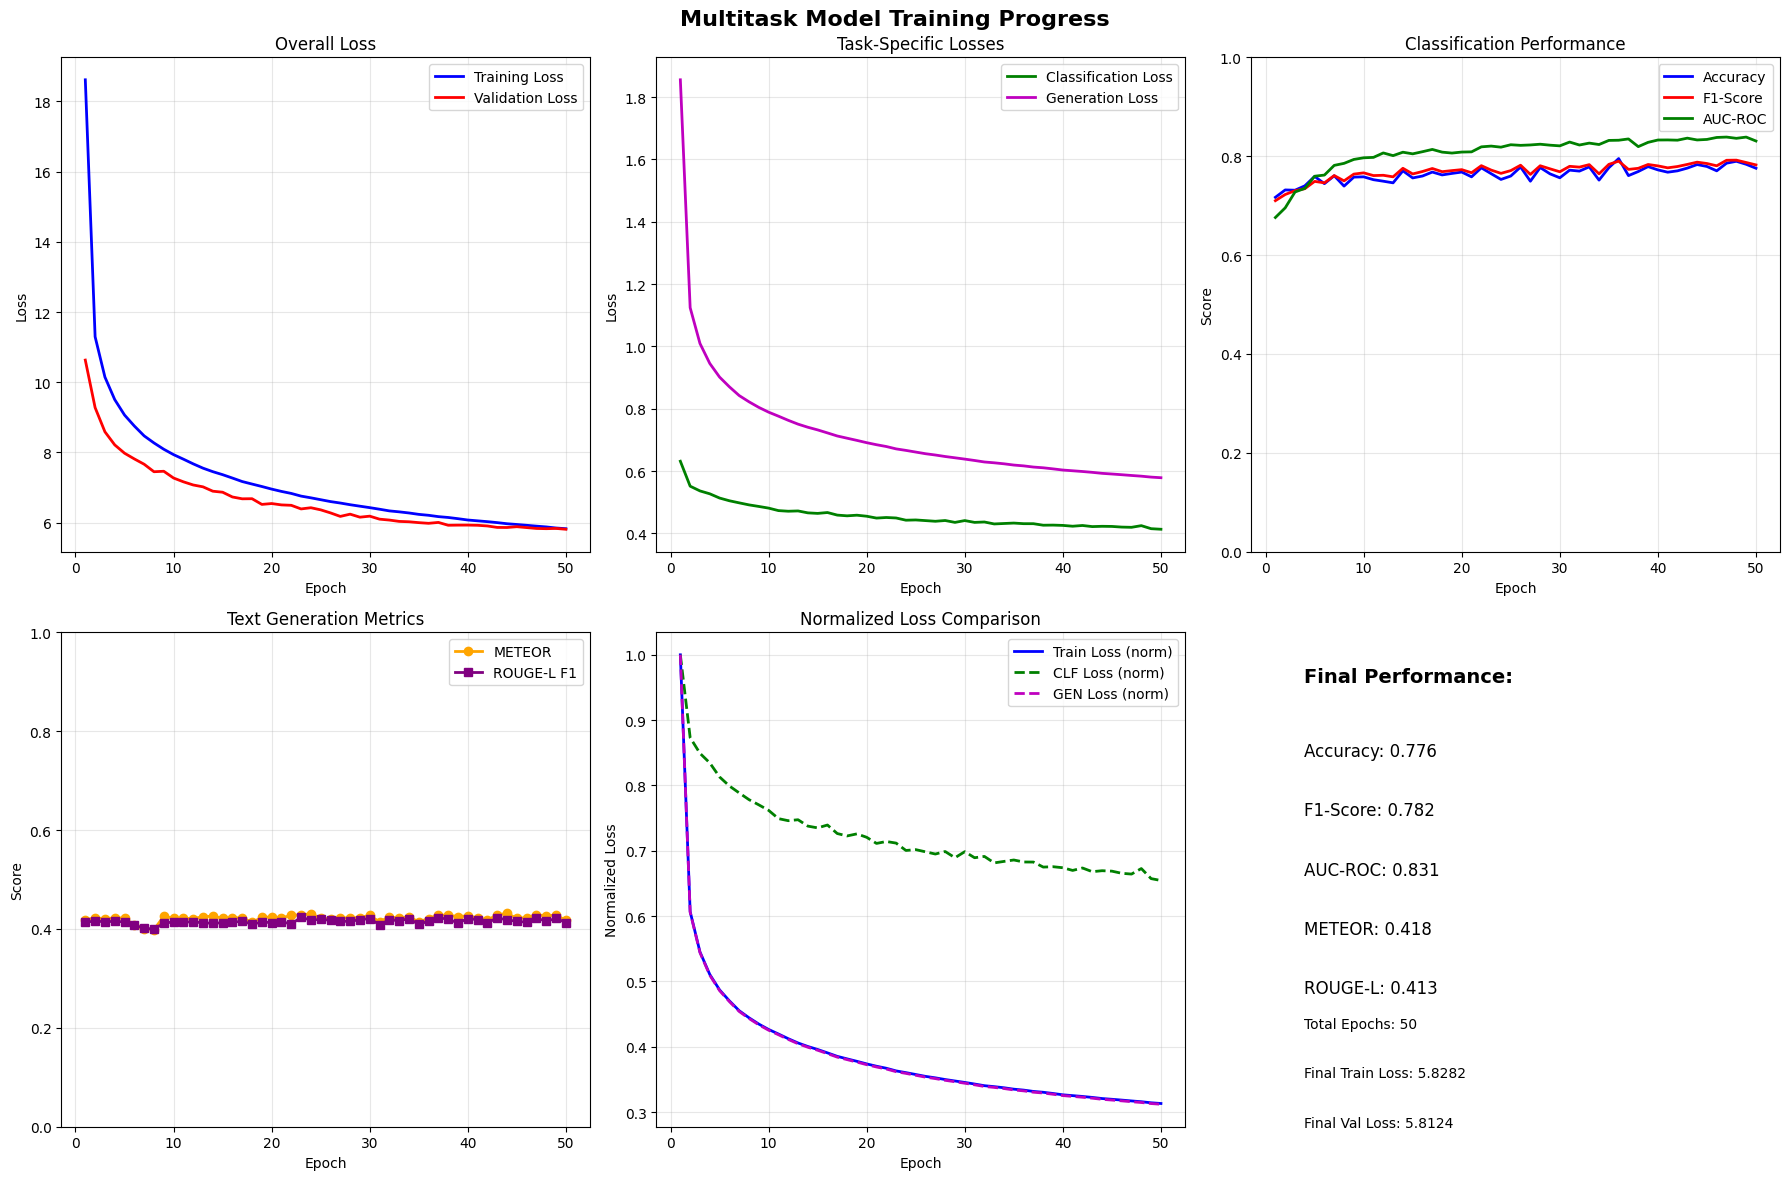


TRAINING SUMMARY
Best Accuracy: 0.7953
Best F1-Score: 0.7921
Best AUC-ROC: 0.8387
Best METEOR: 0.4314
Best ROUGE-L: 0.4234


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8067
Classification metrics (all 3625 samples):
  Accuracy     : 0.7959
  F1-Score     : 0.8017
  Sensitivity  : 0.8341
  Specificity  : 0.6758
  AUC-ROC      : 0.8505

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4110
  METEOR       : 0.4159

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast scan measurement in a 

## Concat Projections + Minimal Text

### Initialise Model

In [8]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='concat',         
    projection_type='mlp',         
    use_minimal_text=True,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 19.8026
Classification loss: 0.6245
Generation loss: 1.9740
Weighted gen loss: 19.740142
Validation loss: 10.8388
Validation metrics:
  Accuracy     : 0.7395
  F1-Score     : 0.7278
  Sensitivity  : 0.8635
  Specificity  : 0.3512
  AUC-ROC      : 0.6867

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ✓ New best METEOR: 0.4234
  ROUGE-L F1   : 0.4160
  ✓ New best ROUGE-L F1: 0.4160
✓ New best accuracy: 0.7395
✓ New best F1: 0.7278
✓ New best AUC-ROC: 0.6867

Epoch 2/50
Training loss: 11.6471
Classification loss: 0.5519
Generation loss: 1.1592
Weighted gen loss: 11.591945
Validation loss: 9.4640
Validation metrics:
  Accuracy     : 0.7414
  F1-Score     : 0.7393
  Sensitivity  : 0.8369
  Specificity  : 0.4424
  AUC-ROC      : 0.7209

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 17/50
Training loss: 7.4256
Classification loss: 0.4626
Generation loss: 0.7379
Weighted gen loss: 7.379338
Validation loss: 6.8968
Validation metrics:
  Accuracy     : 0.7701
  F1-Score     : 0.7751
  Sensitivity  : 0.8256
  Specificity  : 0.5964
  AUC-ROC      : 0.8096

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ROUGE-L F1   : 0.4160
✓ New best accuracy: 0.7701
✓ New best F1: 0.7751
✓ New best AUC-ROC: 0.8096

Epoch 18/50
Training loss: 7.3501
Classification loss: 0.4557
Generation loss: 0.7305
Weighted gen loss: 7.304549
Validation loss: 6.8147
Validation metrics:
  Accuracy     : 0.7588
  F1-Score     : 0.7667
  Sensitivity  : 0.8041
  Specificity  : 0.6169
  AUC-ROC      : 0.8072

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples.

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.4906
Classification loss: 0.4338
Generation loss: 0.6447
Weighted gen loss: 6.447259
Validation loss: 6.1118
Validation metrics:
  Accuracy     : 0.7580
  F1-Score     : 0.7693
  Sensitivity  : 0.7812
  Specificity  : 0.6853
  AUC-ROC      : 0.8231

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 35/50
Training loss: 6.4512
Classification loss: 0.4352
Generation loss: 0.6408
Weighted gen loss: 6.407693
Validation loss: 6.1065
Validation metrics:
  Accuracy     : 0.7748
  F1-Score     : 0.7822
  Sensitivity  : 0.8143
  Specificity  : 0.6511
  AUC-ROC      : 0.8315

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3

Validation loss: 5.8902
Validation metrics:
  Accuracy     : 0.7765
  F1-Score     : 0.7833
  Sensitivity  : 0.8187
  Specificity  : 0.6442
  AUC-ROC      : 0.8302

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145


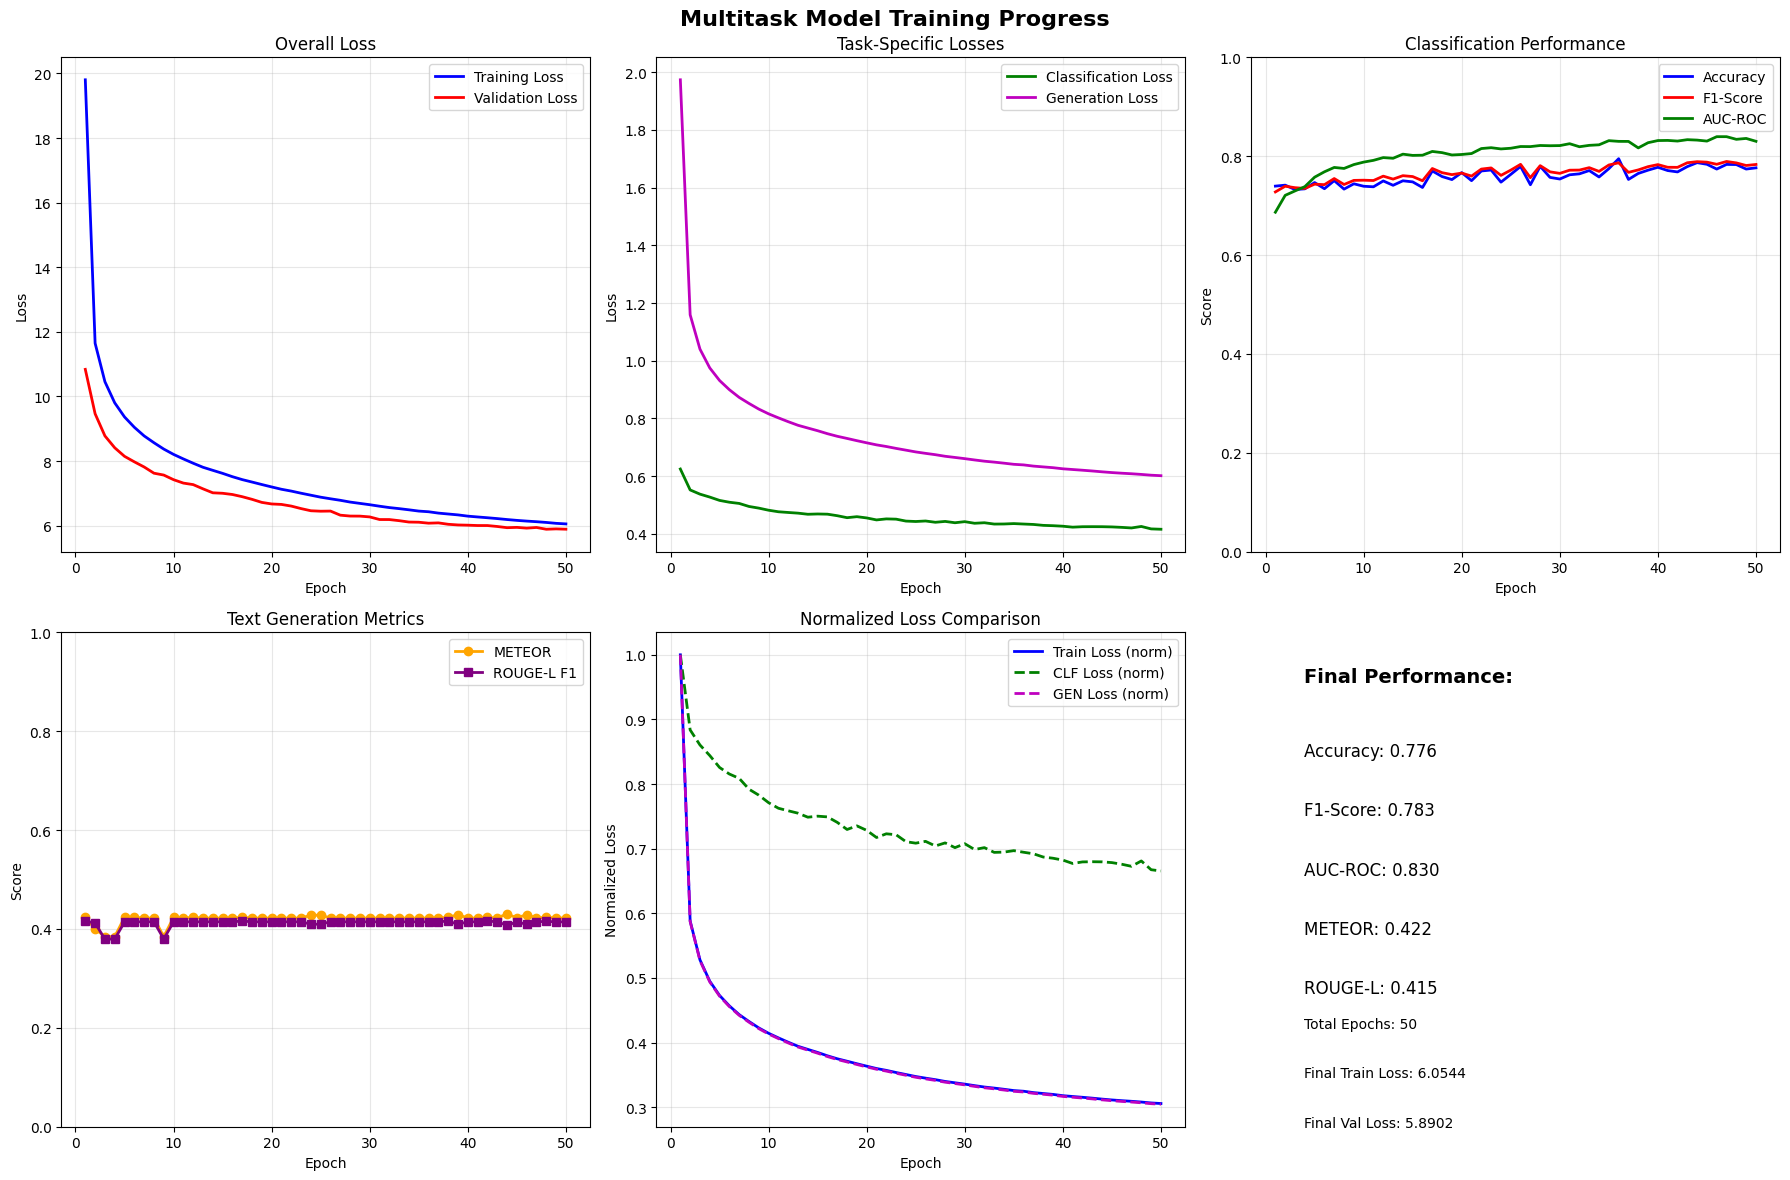


TRAINING SUMMARY
Best Accuracy: 0.7950
Best F1-Score: 0.7893
Best AUC-ROC: 0.8395
Best METEOR: 0.4307
Best ROUGE-L: 0.4160


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [11]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8404
Classification metrics (all 3625 samples):
  Accuracy     : 0.7992
  F1-Score     : 0.8042
  Sensitivity  : 0.8407
  Specificity  : 0.6689
  AUC-ROC      : 0.8529

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4130
  METEOR       : 0.4206

Sample efficiency: 3625/3625 samples used for text metrics


In [12]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a

## Concat + MLP (minimal text) (sampling)

In [13]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='concat',         
    projection_type='mlp',         
    use_minimal_text=True,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp
Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes



Epoch 1/50
Training loss: 19.7948
Classification loss: 0.7030
Generation loss: 1.9725
Weighted gen loss: 19.724545
Validation loss: 10.8259
Validation metrics:
  Accuracy     : 0.7566
  F1-Score     : 0.7278
  Sensitivity  : 0.9145
  Specificity  : 0.2623
  AUC-ROC      : 0.7022
✓ New best accuracy: 0.7566
✓ New best F1: 0.7278
✓ New best AUC-ROC: 0.7022

Epoch 2/50
Training loss: 11.6627
Classification loss: 0.5501
Generation loss: 1.1608
Weighted gen loss: 11.607699
Validation loss: 9.4384
Validation metrics:
  Accuracy     : 0.7638
  F1-Score     : 0.7279
  Sensitivity  : 0.9330
  Specificity  : 0.2338
  AUC-ROC      : 0.7268
✓ New best accuracy: 0.7638
✓ New best F1: 0.7279
✓ New best AUC-ROC: 0.7268

Epoch 3/50
Training loss: 10.4754
Classification loss: 0.5284
Generation loss: 1.0423
Weighted gen loss: 10.422596
Validation loss: 8.8273
Validation metrics:
  Accuracy     : 0.7621
  F1-Score     : 0.7433
  Sensitivity  : 0.8988
  Specificity  : 0.3341
  AUC-ROC      : 0.7408
✓ New

Training loss: 6.8203
Classification loss: 0.4402
Generation loss: 0.6776
Weighted gen loss: 6.776317
Validation loss: 6.3734
Validation metrics:
  Accuracy     : 0.7693
  F1-Score     : 0.7772
  Sensitivity  : 0.8089
  Specificity  : 0.6454
  AUC-ROC      : 0.8254
✓ New best AUC-ROC: 0.8254

Epoch 27/50
Training loss: 6.7738
Classification loss: 0.4445
Generation loss: 0.6729
Weighted gen loss: 6.729348
Validation loss: 6.3243
Validation metrics:
  Accuracy     : 0.7663
  F1-Score     : 0.7752
  Sensitivity  : 0.8009
  Specificity  : 0.6579
  AUC-ROC      : 0.8233
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 6.7293
Classification loss: 0.4395
Generation loss: 0.6685
Weighted gen loss: 6.685379
Validation loss: 6.2874
Validation metrics:
  Accuracy     : 0.7638
  F1-Score     : 0.7732
  Sensitivity  : 0.7969
  Specificity  : 0.6602
  AUC-ROC      : 0.8178

Epoch 29/50
Training loss: 6.6833
Classification loss: 0.4429
Generation loss: 0.6639
Weighted gen lo

/home/s2080063/MWR-to-Text/model_projections.py:990: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


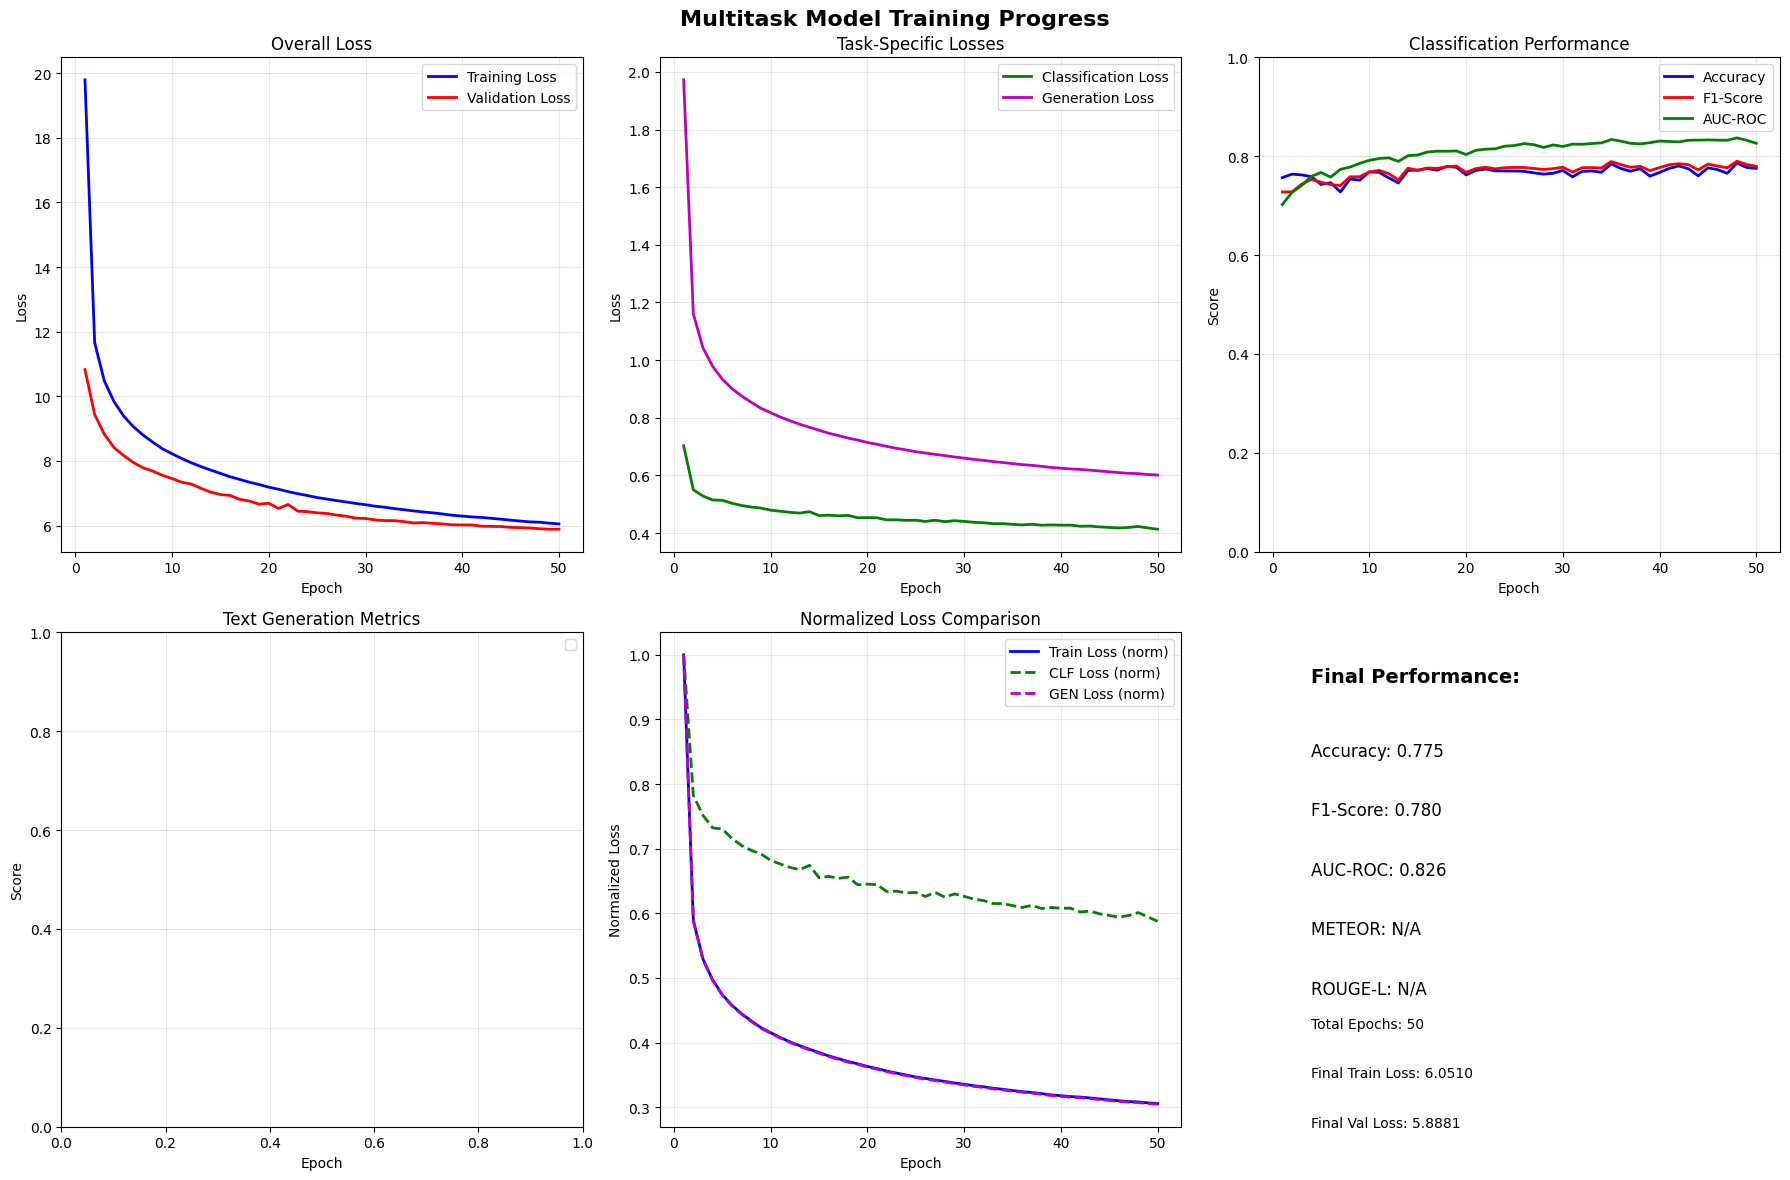


TRAINING SUMMARY
Best Accuracy: 0.7861
Best F1-Score: 0.7900
Best AUC-ROC: 0.8371


In [14]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [15]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8706
Classification metrics (all 3625 samples):
  Accuracy     : 0.7989
  F1-Score     : 0.8024
  Sensitivity  : 0.8498
  Specificity  : 0.6393
  AUC-ROC      : 0.8454

2. Sampled Text Generation Performance:
=== ENCODER EMBEDDING DIAGNOSTIC ===
Embedding variance: 0.269812
Embedding std: 0.506561
Embedding range: 3.760688
Cosine similarity between samples 0 and 1: 0.215454
First 2 samples, first 5 dims:
tensor([[0.0000, 1.2965, 0.9390, 0.9688, 0.0000],
        [1.0870, 0.0000, 0.4437, 0.0000, 0.8265]], device='cuda:1')
=== END DIAGNOSTIC ===

Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3899
  METEOR       : 0.3895

Sample efficiency: 3625/3625 samples used for text metrics


In [16]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 380
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, the asymmetry is currently exceeded, but its distribution does not indicate signs of locally higher metabolism in breast tissue. The next check is recommended no later than 1 year from now (09. 2019). During this period, we advise regular self-examinations
Reference : The measured temperature values are exceeded, but the current distribution of larger markers of locally higher metabolism in breast tissue does not indicate.
----------------------------------------

Sample 1557
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan in one year (December 2010). In the case of noticeable, visible changes, discharge, or prolonged pain, we recommend a 

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
    train_df, val_df, test_df,
    projection_mode='concat',         
    projection_type='mlp',         
    use_minimal_text=False,          
    batch_size=32,
    learning_rate=5e-5
)


EXPERIMENT: CONCAT projection + FULL text
Projection type: mlp


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: False
  Feature projection: Yes



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.6158
Classification loss: 0.6316
Generation loss: 1.8553
Weighted gen loss: 18.552640
Validation loss: 10.6315
Validation metrics:
  Accuracy     : 0.7169
  F1-Score     : 0.7101
  Sensitivity  : 0.8336
  Specificity  : 0.3512
  AUC-ROC      : 0.6760
✓ New best accuracy: 0.7169
✓ New best F1: 0.7101
✓ New best AUC-ROC: 0.6760

Epoch 2/50
Training loss: 11.2931
Classification loss: 0.5478
Generation loss: 1.1238
Weighted gen loss: 11.238361
Validation loss: 9.1837
Validation metrics:
  Accuracy     : 0.7246
  F1-Score     : 0.7276
  Sensitivity  : 0.8074
  Specificity  : 0.4652
  AUC-ROC      : 0.7042
✓ New best accuracy: 0.7246
✓ New best F1: 0.7276
✓ New best AUC-ROC: 0.7042

Epoch 3/50
Training loss: 10.0659
Classification loss: 0.5356
Generation loss: 1.0012
Weighted gen loss: 10.012320
Validation loss: 8.5568
Validation metrics:
  Accuracy     : 0.7127
  F1-Score     : 0.7243
  Sensitivity  : 0.7627
  Specificity  : 0.5564
  AUC-ROC      : 0.7256
✓ New best AUC-RO

Training loss: 6.5804
Classification loss: 0.4398
Generation loss: 0.6536
Weighted gen loss: 6.536456
Validation loss: 6.2572
Validation metrics:
  Accuracy     : 0.7812
  F1-Score     : 0.7804
  Sensitivity  : 0.8588
  Specificity  : 0.5382
  AUC-ROC      : 0.8218
✓ New best F1: 0.7804
✓ New best AUC-ROC: 0.8218

Epoch 27/50
Training loss: 6.5434
Classification loss: 0.4396
Generation loss: 0.6499
Weighted gen loss: 6.499484
Validation loss: 6.1861
Validation metrics:
  Accuracy     : 0.7613
  F1-Score     : 0.7704
  Sensitivity  : 0.7976
  Specificity  : 0.6477
  AUC-ROC      : 0.8196
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 6.4838
Classification loss: 0.4458
Generation loss: 0.6439
Weighted gen loss: 6.439203
Validation loss: 6.1591
Validation metrics:
  Accuracy     : 0.7908
  F1-Score     : 0.7836
  Sensitivity  : 0.8901
  Specificity  : 0.4800
  AUC-ROC      : 0.8234
✓ New best accuracy: 0.7908
✓ New best F1: 0.7836
✓ New best AUC-ROC: 0.8234

Ep

/home/s2080063/MWR-to-Text/model_projections.py:990: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


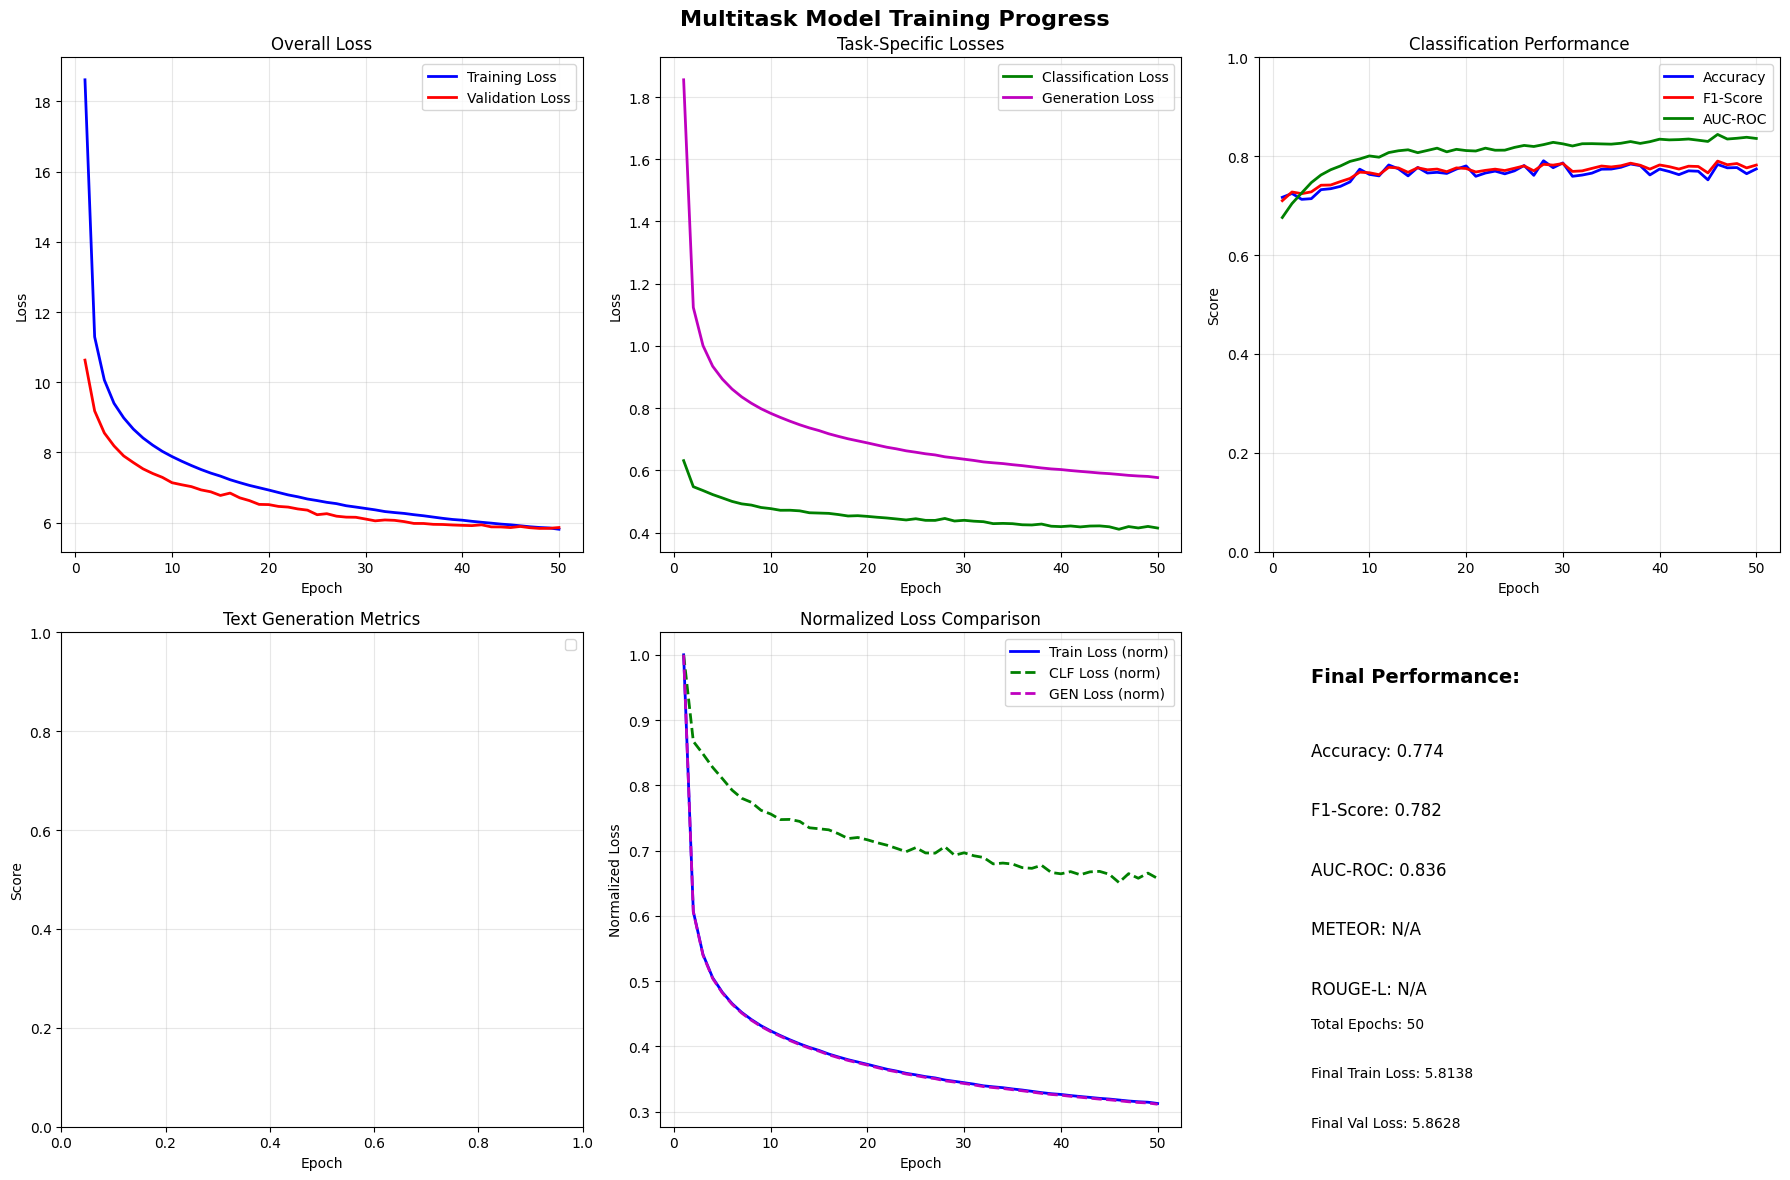


TRAINING SUMMARY
Best Accuracy: 0.7908
Best F1-Score: 0.7901
Best AUC-ROC: 0.8440


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [11]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.8433
Classification metrics (all 3625 samples):
  Accuracy     : 0.7967
  F1-Score     : 0.8031
  Sensitivity  : 0.8308
  Specificity  : 0.6895
  AUC-ROC      : 0.8566

2. Sampled Text Generation Performance:
=== ENCODER EMBEDDING DIAGNOSTIC ===
Embedding variance: 0.270758
Embedding std: 0.507946
Embedding range: 4.196687
Cosine similarity between samples 0 and 1: 0.277054
First 2 samples, first 5 dims:
tensor([[0.8653, 0.6051, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.5407, 1.9151, 0.0000]], device='cuda:1')
=== END DIAGNOSTIC ===

Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4051
  METEOR       : 0.4048

Sample efficiency: 3625/3625 samples used for text metrics


In [12]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally elevated metabolism in the breast tissue. We recommend the next check-up in 1 year (April 2017). During this period, we advise regular self-examinations and occasional preventive ultrasound examinations by a specialist. In case of noticeable changes, discharge
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, the asymmetry on the surface is exceeded, but the current distribution does not indicate signs of locally higher metabolism in breast tissue. We recommend the next check-up in 1 year (06.2016). During this period, we advise regular self-examination
Refer